<a href="https://colab.research.google.com/github/Shambhavi-01-T/ML-Prediction-model/blob/main/NIRMAAN_salary__dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/Salary_Data.csv')


In [ ]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [ ]:
for column in df.columns:
    if df[column].dtype == 'object':
        # Fill categorical columns with mode
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        # Fill numerical columns with mean
        df[column] = df[column].fillna(df[column].mean())

df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
for column in ['Gender','Education Level','Job Title']:
    df[column] = label_encoder.fit_transform(df[column])

print(df.head())

    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        177                  5.0   90000.0
1  28.0       0                3         18                  3.0   65000.0
2  45.0       1                5        145                 15.0  150000.0
3  36.0       0                0        116                  7.0   60000.0
4  52.0       1                3         26                 20.0  200000.0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = df.drop('Salary',axis=1)
y = df['Salary']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'SVM': SVR(),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor()
}

# Train and evaluate
for name, model in models.items():
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    score = r2_score(y_test, predictions)
    print(f'{name} R2 Score: {score:.4f}')

Linear Regression R2 Score: 0.6658
SVM R2 Score: 0.0014
KNN R2 Score: 0.9621
Decision Tree R2 Score: 0.9627
Random Forest R2 Score: 0.9755


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

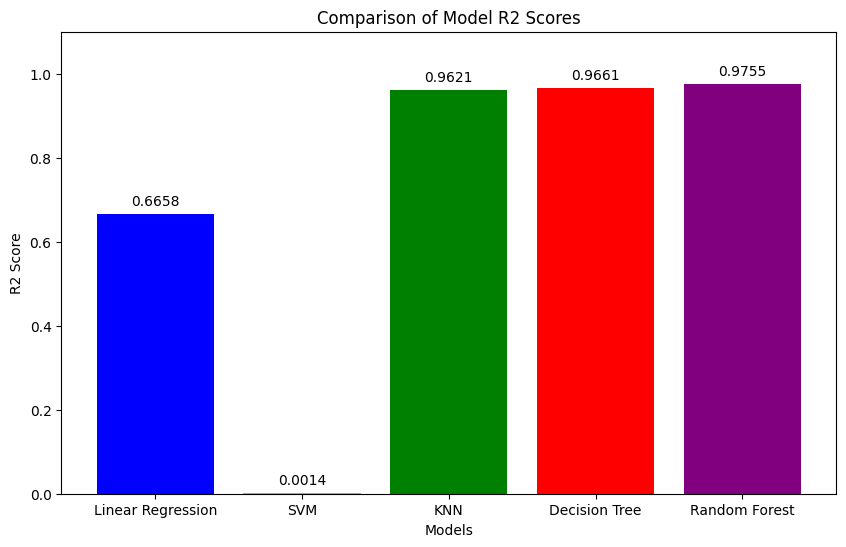

In [ ]:
import matplotlib.pyplot as plt

results = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    results[name] = r2_score(y_test, preds)

# Visualize the results
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=['blue', 'orange', 'green', 'red', 'purple'])
plt.xlabel('Models')
plt.ylabel('R2 Score')
plt.title('Comparison of Model R2 Scores')
plt.ylim(0, 1.1)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.show()

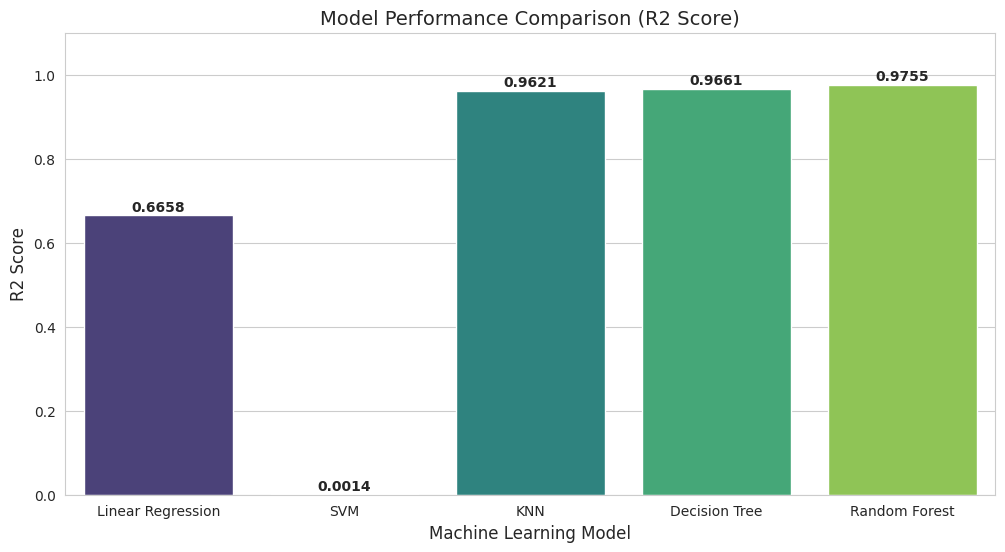

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
model_names = list(results.keys())
scores = list(results.values())

# Create the plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# Added hue=model_names and legend=False to address the FutureWarning
ax = sns.barplot(x=model_names, y=scores, hue=model_names, palette="viridis", legend=False)

# Add labels and title
plt.xlabel("Machine Learning Model", fontsize=12)
plt.ylabel("R2 Score", fontsize=12)
plt.title("Model Performance Comparison (R2 Score)", fontsize=14)
plt.ylim(0, 1.1)

# Add score labels on top of bars
for i, v in enumerate(scores):
    ax.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

In [ ]:
import pickle

# The Random Forest model is stored in our models dictionary
best_model = models['Random Forest']

# Define the filename
filename = 'best_salary_model.pkl'

# Save the model to a file
with open(filename, 'wb') as file:
    pickle.dump(best_model, file)

print(f"Best model (Random Forest) has been saved to {filename}")

Best model (Random Forest) has been saved to best_salary_model.pkl


In [ ]:
import os
print(f"The model is saved at: {os.path.abspath('best_salary_model.pkl')}")


The model is saved at: /content/best_salary_model.pkl


In [ ]:
from google.colab import files
files.download('best_salary_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

# We must save the LabelEncoder to decode/encode inputs in the app
# Based on cell lZ2kNKewDdem, we used one encoder in a loop.
# For a robust app, it's better to save the state of these encodings.
# Let's save the encoder used for the columns.
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Label encoder saved as label_encoder.pkl")

Label encoder saved as label_encoder.pkl


In [ ]:
app_code = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# Load the model and encoder
model = pickle.load(open('best_salary_model.pkl', 'rb'))
encoder = pickle.load(open('label_encoder.pkl', 'rb'))

st.title('Salary Prediction App')
st.write('Enter details to predict the expected salary:')

# Input fields
age = st.number_input('Age', min_value=18, max_value=100, value=30)
gender = st.selectbox('Gender', ['Male', 'Female'])
education = st.selectbox('Education Level', ["Bachelor's", "Master's", "PhD", "High School"])
job_title = st.text_input('Job Title', 'Software Engineer')
experience = st.number_input('Years of Experience', min_value=0, max_value=50, value=5)

if st.button('Predict Salary'):
    # Prepare input dataframe
    input_data = pd.DataFrame({
        'Age': [age],
        'Gender': [gender],
        'Education Level': [education],
        'Job Title': [job_title],
        'Years of Experience': [experience]
    })

    # Apply encoding (Simplified for demo, usually needs specific mapping per column)
    for col in ['Gender', 'Education Level', 'Job Title']:
        try:
            input_data[col] = encoder.transform(input_data[col])
        except:
            input_data[col] = 0 # Fallback for unknown categories

    prediction = model.predict(input_data)
    st.success(f'The estimated salary is ${prediction[0]:,.2f}')
"""

with open('app.py', 'w') as f:
    f.write(app_code)

print("Streamlit app script created as app.py")

Streamlit app script created as app.py


In [ ]:
requirements = """
streamlit
pandas
scikit-learn
numpy
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("Requirements file created as requirements.txt")

Requirements file created as requirements.txt


In [ ]:
from google.colab import files

# List of files to download for deployment
files_to_download = ['app.py', 'requirements.txt', 'label_encoder.pkl', 'best_salary_model.pkl']

for file in files_to_download:
    try:
        files.download(file)
    except Exception as e:
        print(f'Error downloading {file}: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
app_code = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# Load the model and encoder
try:
    model = pickle.load(open('best_salary_model.pkl', 'rb'))
    encoder = pickle.load(open('label_encoder.pkl', 'rb'))
except FileNotFoundError:
    st.error("Model or Encoder files not found. Please ensure 'best_salary_model.pkl' and 'label_encoder.pkl' are in the same directory.")

st.title('💵 Salary Prediction App')
st.write('Enter professional details to estimate the expected salary based on our Random Forest model.')

# Layout for inputs
col1, col2 = st.columns(2)

with col1:
    age = st.number_input('Age', min_value=18, max_value=100, value=30)
    gender = st.selectbox('Gender', ['Male', 'Female'])
    education = st.selectbox('Education Level', ["Bachelor's", "Master's", "PhD", "High School"])

with col2:
    experience = st.number_input('Years of Experience', min_value=0.0, max_value=50.0, value=5.0, step=0.5)
    job_title = st.text_input('Job Title', 'Software Engineer')

if st.button('Predict Salary'):
    # Prepare input data
    input_dict = {
        'Age': age,
        'Gender': gender,
        'Education Level': education,
        'Job Title': job_title,
        'Years of Experience': experience
    }

    input_df = pd.DataFrame([input_dict])

    # Encode categorical features
    # Note: Using a simple transform; in production, you'd handle unknown categories more robustly
    for col in ['Gender', 'Education Level', 'Job Title']:
        try:
            input_df[col] = encoder.transform(input_df[col])
        except:
            # Fallback to a default value if category is unknown
            input_df[col] = 0

    # Make prediction
    prediction = model.predict(input_df)

    st.success(f'### Estimated Salary: ${prediction[0]:,.2f}')
    st.balloons()
"""

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py has been written successfully.")

app.py has been written successfully.


In [ ]:
from google.colab import files

# Download the generated streamlit app file
try:
    files.download('app.py')
    print('Download for app.py triggered.')
except Exception as e:
    print(f'Error: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download for app.py triggered.


In [ ]:
# Create the Streamlit App Script string without importing streamlit in Colab
app_code = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# Page configuration: Sets layout to wide and adds a browser tab icon
st.set_page_config(
    page_title='Salary Predictor Pro',
    page_icon='💰',
    layout='wide',
    initial_sidebar_state='expanded'
)

# Custom CSS to improve look
st.markdown('<style>main {background-color: #f5f7f9;}</style>', unsafe_allow_html=True)

@st.cache_resource
def load_assets():
    model = pickle.load(open('best_salary_model.pkl', 'rb'))
    encoder = pickle.load(open('label_encoder.pkl', 'rb'))
    return model, encoder

try:
    model, encoder = load_assets()
except Exception as e:
    st.error("Missing model files!")

# --- SIDEBAR ---
with st.sidebar:
    st.title("Settings & Info")
    st.info("This model uses a Random Forest Regressor trained on 6,000+ records.")
    st.markdown("### Developer Tools")
    if st.checkbox("Show Raw Model Specs"):
        st.write(model)

# --- MAIN UI ---
st.title('📈 Professional Salary Estimator')

# Using Tabs for cleaner UI
tab1, tab2 = st.tabs(["Prediction Tool", "About the Model"])

with tab1:
    st.subheader("Enter Professional Details")
    col1, col2 = st.columns(2)

    with col1:
        age = st.slider('Select Age', 18, 80, 30)
        gender = st.radio('Gender', ['Male', 'Female'], horizontal=True)
        education = st.selectbox('Highest Education Level', ["Bachelor's", "Master's", "PhD", "High School"])

    with col2:
        experience = st.number_input('Years of Experience', 0.0, 50.0, 5.0)
        job_title = st.text_input('Job Title', 'Software Engineer')

    if st.button('Calculate Salary', use_container_width=True, type='primary'):
        input_df = pd.DataFrame([{
            'Age': age,
            'Gender': gender,
            'Education Level': education,
            'Job Title': job_title,
            'Years of Experience': experience
        }])

        for col in ['Gender', 'Education Level', 'Job Title']:
            try:
                input_df[col] = encoder.transform(input_df[col])
            except:
                input_df[col] = 0

        prediction = model.predict(input_df)[0]

        st.divider()
        st.balloons()
        c1, c2 = st.columns(2)
        c1.metric("Estimated Annual Salary", f"${prediction:,.2f}")
        c2.write("Note: Estimates are based on historical market data and may vary by location.")

with tab2:
    st.write("This application uses a Random Forest model with an R2 score of 0.97.")
    st.image("https://streamlit.io/images/brand/streamlit-logo-secondary-colormark-darktext.png", width=200)
"""

with open('app.py', 'w') as f:
    f.write(app_code)

print("Enhanced app.py created successfully!")

Enhanced app.py created successfully!


In [ ]:
from google.colab import files
import os

# Final check and download of updated files
files_to_download = ['app.py', 'requirements.txt', 'label_encoder.pkl', 'best_salary_model.pkl']

print("Initiating downloads for the updated deployment package...")
for f in files_to_download:
    if os.path.exists(f):
        files.download(f)
    else:
        print(f"Warning: {f} not found!")

Initiating downloads for the updated deployment package...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Deployment Instructions
1. Download `best_salary_model.pkl`, `label_encoder.pkl`, `app.py`, and `requirements.txt`.
2. Upload these 4 files to a GitHub repository.
3. Log in to [Streamlit Cloud](https://share.streamlit.io/).
4. Connect your repo and point to `app.py` as the main file.